# Машинное обучение, ФКН ВШЭ

# Практическое задание 11. Несбалансированные задачи

## Общая информация
Дата выдачи: 24.04.2025

Мягкий дедлайн: 13.05.2025 23:59 MSK

Жесткий дедлайн: 18.05.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-xx-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты мы обойдемся бинарной задачей, тем не менее, во многом данные методы можно перенести и на задачи с б**о**льшим числом классов. Кроме того, вы получите очередной бесценный опыт исследования случайной библиотеки случайных индусов с нуля.

In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm

**Задание -1 (1 балл)**. EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [3]:
"""%%bash
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip creditcardfraud.zip""";

In [4]:
df = pd.read_csv('creditcard.csv')

In [5]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Скажите, какова доля положительных объектов в выборке?

In [6]:
df[df['Class'] == 1].shape[0] / df.shape[0]

0.001727485630620034

Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуйте по ним создать признаки "час" (от 0 до 23) и "день" (от 0 до ...) в аналогичной манере (принимая первый объект выборки за начальную точку). Сколько дней покрывают данные?

In [7]:
df['Hour'] = (df['Time'] // 3600 % 24).astype(int)
df['Day'] = (df['Time'] // (3600 * 24)).astype(int)

In [8]:
num_days = df['Day'].max() - df['Day'].min() + 1
print(f"Данные покрывают {num_days} дня")

Данные покрывают 2 дня


Постройте следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? На ваш взгляд, как можно связать полученные нами часы с реальными часами в сутках?

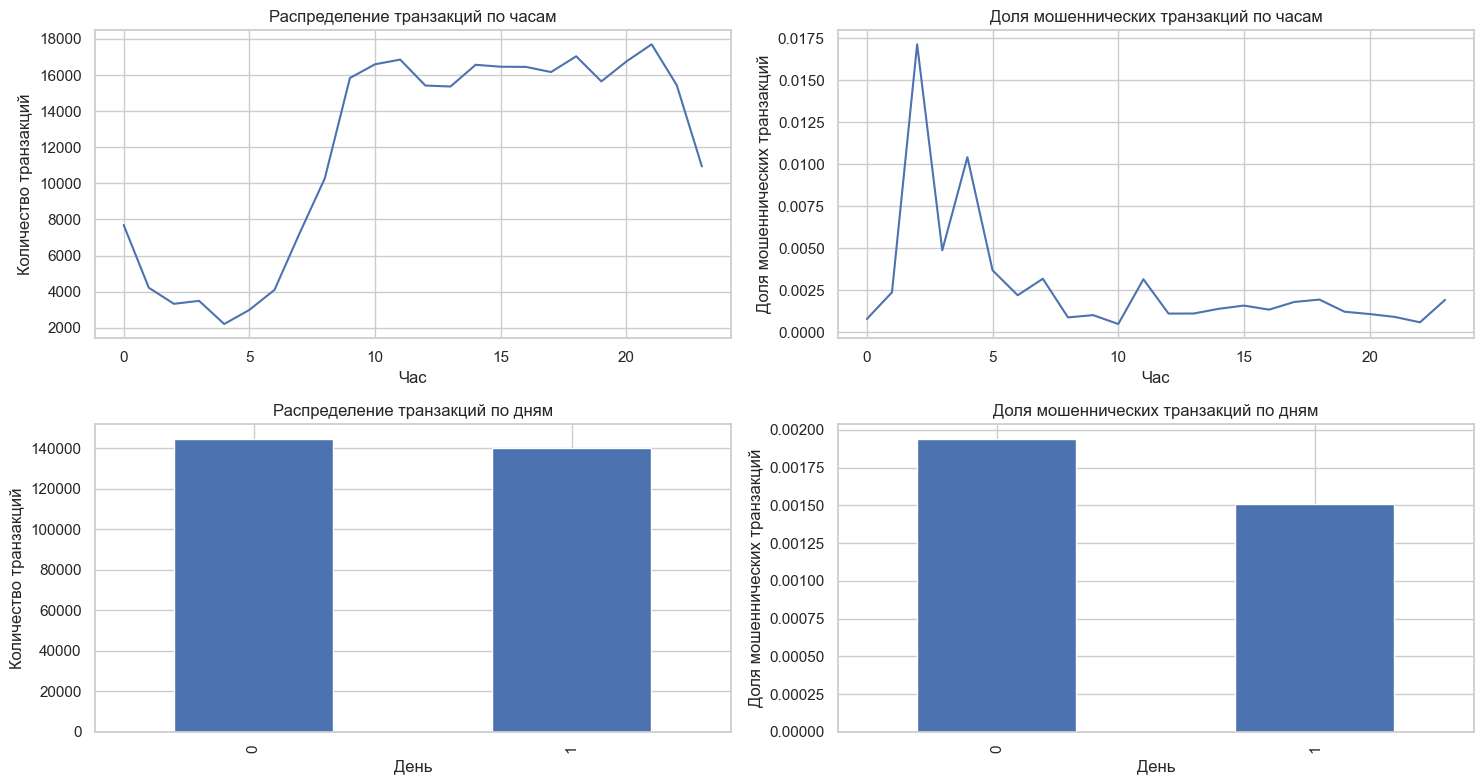

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

plt.subplot(2, 2, 1)
df.groupby('Hour').size().plot(kind='line')
plt.title('Распределение транзакций по часам')
plt.xlabel('Час')
plt.ylabel('Количество транзакций')

plt.subplot(2, 2, 2)
(df[df['Class'] == 1].groupby('Hour').size() / df.groupby('Hour').size()).plot(kind='line')
plt.title('Доля мошеннических транзакций по часам')
plt.xlabel('Час')
plt.ylabel('Доля мошеннических транзакций')

plt.subplot(2, 2, 3)
df.groupby('Day').size().plot(kind='bar')
plt.title('Распределение транзакций по дням')
plt.xlabel('День')
plt.ylabel('Количество транзакций')

plt.subplot(2, 2, 4)
(df[df['Class'] == 1].groupby('Day').size() / df.groupby('Day').size()).plot(kind='bar')
plt.title('Доля мошеннических транзакций по дням')
plt.xlabel('День')
plt.ylabel('Доля мошеннических транзакций')

plt.tight_layout()
plt.show()

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуйте (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']] = scaler.fit_transform(df[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']])

Топ-5 важных признаков: Index(['V11', 'V4', 'V2', 'V21', 'V19'], dtype='object')


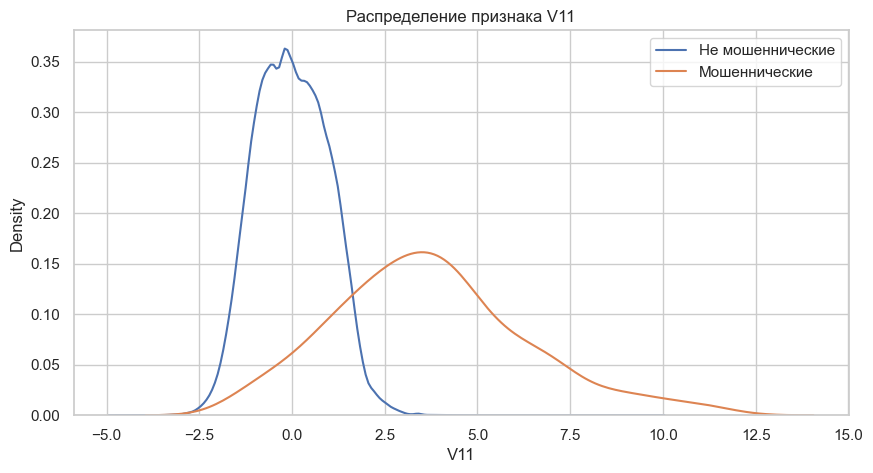

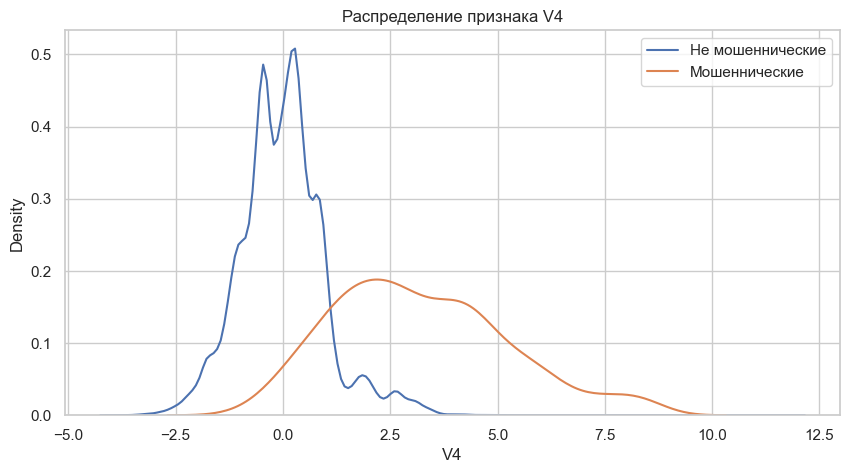

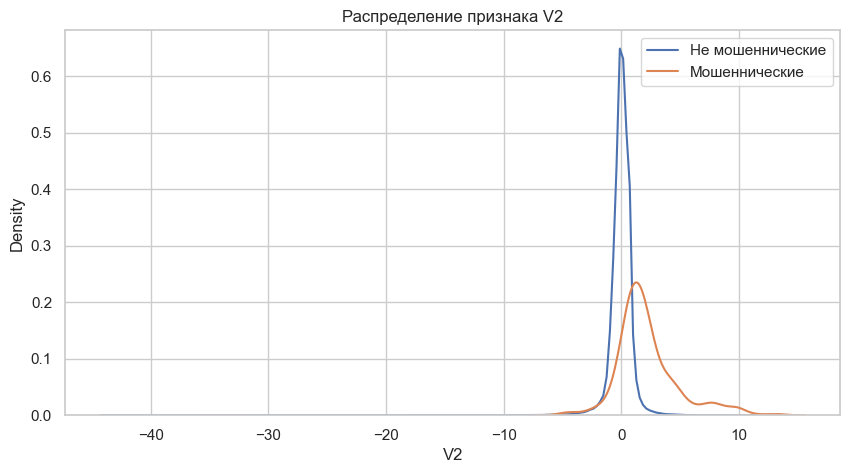

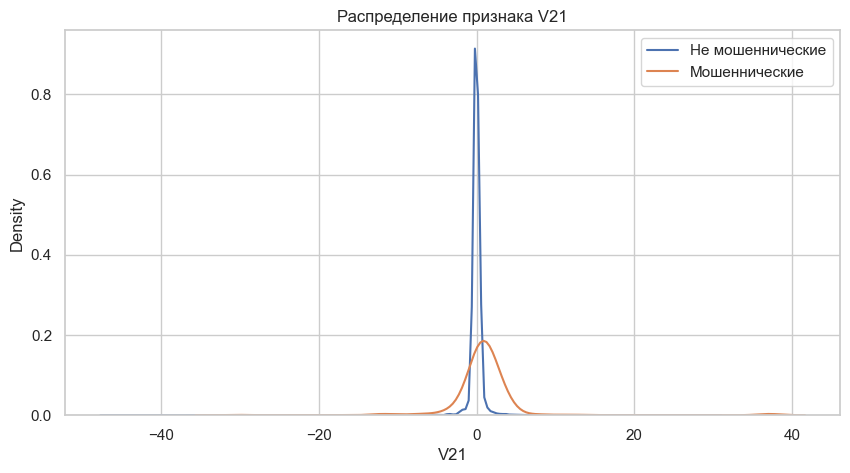

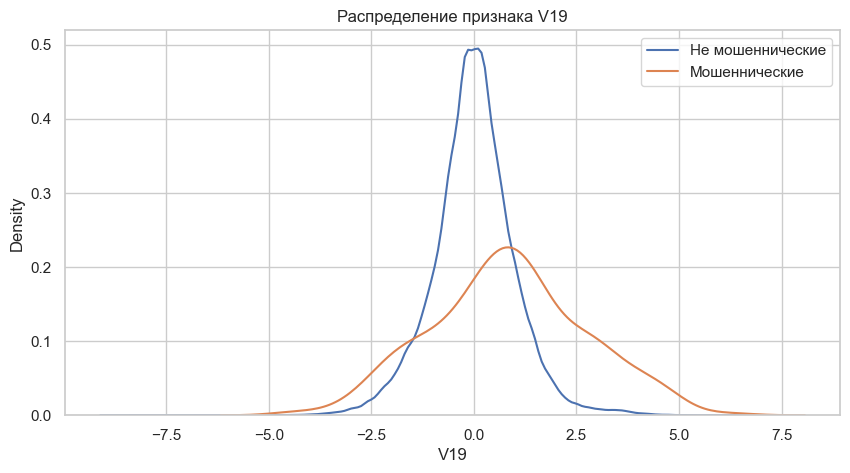

In [11]:
correlations = df.corr()['Class'].sort_values(ascending=False)

top_features = correlations.index[1:6]
print("Топ-5 важных признаков:", top_features)

for feature in top_features:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[df['Class'] == 0][feature], label='Не мошеннические')
    sns.kdeplot(df[df['Class'] == 1][feature], label='Мошеннические')
    plt.title(f'Распределение признака {feature}')
    plt.legend()
    plt.show()

Теперь давайте разделим данные. Отделите хронологически последние 20% транзакций и поделите их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (как можно было заметить, мошеннические транзакции имеют разное распределение во времени - по-хорошему, нам стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, мы не сможем получить больше данных для адекватного контроля, поэтому обойдемся этим. 

In [12]:
df = df.sort_values('Time')

In [13]:
train_size = int(0.8 * len(df))
val_size = int(0.1 * len(df))

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size+val_size]
test_df = df.iloc[train_size+val_size:]

features = [i for i in df.columns if i not in ['Time', 'Class']]
X_train, y_train = train_df[features], train_df['Class']
X_val, y_val = val_df[features], val_df['Class']
X_test, y_test = test_df[features], test_df['Class']

# Часть 1. Несбалансированная классификация.

**Задание 0. (1 балл)**: перед началом работы давайте поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего "ломаются" на задачах с сильным перекосом. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)? (можете не отвечать, просто подумайте)

Из курса МО-1 вам уже известно, что мы можем использовать в таких задачах `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога. 

In [14]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc_score(y_true, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    return auc(recall, precision)

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можете использовать это для отладки):

In [15]:
from sklearn.metrics import confusion_matrix

def kappa_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    n = cm.sum()
    
    po = np.diag(cm).sum() / n
    
    pe = (cm.sum(axis=0) @ cm.sum(axis=1)) / (n ** 2)
    
    kappa = (po - pe) / (1 - pe)
    return kappa

Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$ 

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом. 

In [16]:
def mcc_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу. Вычислите их значения для наивного предсказания (aka мажорный класс для всех объектов):

In [177]:
#your code here
y_1 = np.ones_like(y_train) * np.round(y_train.mean())
y_2 = np.ones_like(y_val) * np.round(y_train.mean())
y_3 = np.ones_like(y_test) * np.round(y_train.mean())

print(f'Train pr-auc score: {pr_auc_score(y_train, y_1)}')
print(f'Val pr-auc score: {pr_auc_score(y_val, y_2)}')
print(f'Test pr-auc score: {pr_auc_score(y_test, y_3)}')

print(f'Train kappa score: {kappa_score(y_train, y_1)}')
print(f'Val kappa scorel: {kappa_score(y_val, y_2)}')
print(f'Test kappa score: {kappa_score(y_test, y_3)}')

print(f'Train mcc score: {mcc_score(y_train, y_1)}')
print(f'Val mcc score: {mcc_score(y_val, y_2)}')
print(f'Test mcc score: {mcc_score(y_test, y_3)}')

Train pr-auc score: 0.5009150957888038
Val pr-auc score: 0.5009304775280898
Test pr-auc score: 0.5003862088336494
Train kappa score: 0.0
Val kappa scorel: 0.0
Test kappa score: 0.0
Train mcc score: nan
Val mcc score: nan
Test mcc score: nan


/var/folders/yl/bg_6c7_56kl413fpblgzt_5w0000gn/T/ipykernel_55356/3590937802.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
/var/folders/yl/bg_6c7_56kl413fpblgzt_5w0000gn/T/ipykernel_55356/3590937802.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
/var/folders/yl/bg_6c7_56kl413fpblgzt_5w0000gn/T/ipykernel_55356/3590937802.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))


Давайте запустим бейзлайн-решение для нашей задачи. С чего же начнем? Возьмите `catboost` и обучите его классификатор на наших данных (используйте все признаки). Вычислите значения всех метрик на тестовой части, для контроля переобучения используйте валидационную (здесь и далее везде, где фигурирует `catboost`). 

In [17]:
from catboost import CatBoostClassifier

In [ ]:
model = CatBoostClassifier(iterations=1000, 
                         random_seed=42,
                         early_stopping_rounds=50,
                         verbose=0)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.5).astype(int)

print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))

PR-AUC: 0.7300869636400436
Kappa: 0.7177586595198053
MCC: 0.7237392787305933


Если вы все сделали правильно, у вас должны были получиться значения в районе 0.7.

**Задание 1. (1 балл)**. Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - просто добавить вес в функции потерь для минорного класса (таким образом, ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это также реализовано, причем для бинарной задачи это можно сделать целыми двумя способами (можете выбрать любой, на свой вкус, автор задания предпочитает отдельный скейлинг для минорного класса). Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Попробуйте обучить модель с таким скалированием и сравните метрики на тестовой части с бейзлайном.

In [ ]:
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

weighted_model = CatBoostClassifier(
    iterations=1000,
    random_state=42,
    early_stopping_rounds=50,
    verbose=0,
    scale_pos_weight=scale_pos_weight
)
weighted_model.fit(X_train, y_train)

y_probs = weighted_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs > 0.5).astype(int)

print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))

PR-AUC: 0.6714340010105757
Kappa: 0.6663875044656185
MCC: 0.6687173894415686


Поскольку данный вес будет являться гиперпараметром метода, было бы опрометчиво остановиться на одном значении (тем более, с большой вероятностью у вас все сломалось). Запустите перебор для этого гиперпараметра на валидационной выборке (используйте `PR-AUC`), подберите оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислите все метрики на тестовой части. 

При этом можете также проверить отдельное скалирование в большую сторону для мажорного класса (т.е. веса минорного сделать меньше 1) и экстремальные скалирования (т.е. веса минорного больше, чем в начале этого задания). Какой вес получился оптимальным?

In [ ]:
import optuna

def objective(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 1, 100)
    threshold = trial.suggest_float('threshold', 0, 1)
    
    model = CatBoostClassifier(
        iterations=1000,
        random_seed=42,
        scale_pos_weight=scale_pos_weight,
        # eval_metric='AUC',
        early_stopping_rounds=50,
        verbose=0
    )
    
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba > threshold).astype(int)
    
    return pr_auc_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_params = study.best_params
print("Best params:", best_params)

best_model = CatBoostClassifier(
    iterations=1000,
    random_seed=42,
    scale_pos_weight=best_params['scale_pos_weight'],
    early_stopping_rounds=50,
    verbose=0
)

best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > best_params['threshold']).astype(int)

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))

[I 2025-05-18 17:28:36,437] A new study created in memory with name: no-name-c0b875a3-542f-4a02-b026-7623d21ec419


[I 2025-05-18 17:28:37,395] Trial 0 finished with value: 0.8012172575213208 and parameters: {'scale_pos_weight': 19.514261546587647, 'threshold': 0.5252848862805616}. Best is trial 0 with value: 0.8012172575213208.
[I 2025-05-18 17:28:38,256] Trial 1 finished with value: 0.7879313112555243 and parameters: {'scale_pos_weight': 75.03534810132719, 'threshold': 0.5021004001148056}. Best is trial 0 with value: 0.8012172575213208.
[I 2025-05-18 17:28:39,178] Trial 2 finished with value: 0.8081842389542206 and parameters: {'scale_pos_weight': 84.79865051033599, 'threshold': 0.6995712941641405}. Best is trial 2 with value: 0.8081842389542206.
[I 2025-05-18 17:28:40,154] Trial 3 finished with value: 0.5368024607688804 and parameters: {'scale_pos_weight': 60.82024752853718, 'threshold': 0.06985860412948108}. Best is trial 2 with value: 0.8081842389542206.
[I 2025-05-18 17:28:41,103] Trial 4 finished with value: 0.6123797310527812 and parameters: {'scale_pos_weight': 69.60852148460957, 'threshold

Best params: {'scale_pos_weight': 58.89466621252626, 'threshold': 0.8189340294111201}

Test metrics:
PR-AUC: 0.7847943248972153
Kappa: 0.7803305436677321
MCC: 0.7824309153418235


In [ ]:
import optuna

def objective(trial):
    scale_pos_weight = trial.suggest_float('scale_pos_weight', 1, 100)
    threshold = trial.suggest_float('threshold', 0, 1)
    
    model = CatBoostClassifier(
        iterations=1000,
        random_seed=42,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=50,
        verbose=0
    )
    
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_proba > threshold).astype(int)
    
    return kappa_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_params = study.best_params
print("Best params:", best_params)

best_model = CatBoostClassifier(
    iterations=1000,
    random_seed=42,
    scale_pos_weight=best_params['scale_pos_weight'],
    early_stopping_rounds=50,
    verbose=0
)

best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > best_params['threshold']).astype(int)

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))

[I 2025-05-18 17:29:19,178] A new study created in memory with name: no-name-c598b8d4-b8ad-45e4-8433-49c0191ccee0
[I 2025-05-18 17:29:20,208] Trial 0 finished with value: 0.7923890347535508 and parameters: {'scale_pos_weight': 32.51066806308151, 'threshold': 0.4092812861212458}. Best is trial 0 with value: 0.7923890347535508.
[I 2025-05-18 17:29:21,144] Trial 1 finished with value: 0.7581317815397028 and parameters: {'scale_pos_weight': 41.21310362595872, 'threshold': 0.3545425376840622}. Best is trial 0 with value: 0.7923890347535508.
[I 2025-05-18 17:29:22,215] Trial 2 finished with value: 0.8418450229309994 and parameters: {'scale_pos_weight': 56.458307923001875, 'threshold': 0.8769801513274784}. Best is trial 2 with value: 0.8418450229309994.
[I 2025-05-18 17:29:23,151] Trial 3 finished with value: 0.8330550184244785 and parameters: {'scale_pos_weight': 91.04194208584747, 'threshold': 0.8987466727722523}. Best is trial 2 with value: 0.8418450229309994.
[I 2025-05-18 17:29:24,067] T

Best params: {'scale_pos_weight': 32.273227085711795, 'threshold': 0.694394507870872}

Test metrics:
PR-AUC: 0.7822084461262145
Kappa: 0.769075266879885
MCC: 0.7754834742272992


**Задание 2. (1 балл)**. На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса. 

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [88]:
# !pip3 install imbalanced-learn
# !conda install -c conda-forge imbalanced-learn

Первый метод, которым мы воспользуемся, называется SMOTE (его вы уже разбирали на лекции). Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку. 

In [87]:
from imblearn.over_sampling import SMOTE

Используйте SMOTE для ресэмплинга обучающей выборки, на новой выборке обучите модель (вес положительных объектов скалировать не нужно). Замерьте качество на тестовой выборке (**важно!** не преобразовывайте валидационную и тестовую выборку никак - мы не хотим отслеживать качество на объектах, которых в реальности не существует). Сравните полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [ ]:
best = 0.8189340294111201
smote = SMOTE(random_state=42)
smote_1 = SMOTE(random_state=42, sampling_strategy=1/2)
smote_2 = SMOTE(random_state=42, sampling_strategy=1/10)

model = CatBoostClassifier(
    iterations=1000,
    random_seed=42,
    early_stopping_rounds=50,
    verbose=0
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_smote_1, y_train_smote_1 = smote_1.fit_resample(X_train, y_train)
X_train_smote_2, y_train_smote_2 = smote_2.fit_resample(X_train, y_train)

y_proba = model.fit(X_train_smote, y_train_smote).predict_proba(X_test)[:, 1] 
y_pred = (y_proba > best).astype(int)

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))

y_proba = model.fit(X_train_smote_1, y_train_smote_1).predict_proba(X_test)[:, 1] 
y_pred = (y_proba > best).astype(int)

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))

y_proba = model.fit(X_train_smote_2, y_train_smote_2).predict_proba(X_test)[:, 1] 
y_pred = (y_proba > best).astype(int)

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))


Test metrics:
PR-AUC: 0.7357688176432424
Kappa: 0.7315151089271766
MCC: 0.7334840868512968

Test metrics:
PR-AUC: 0.757698642204646
Kappa: 0.7498260851234142
MCC: 0.7536088677841671

Test metrics:
PR-AUC: 0.7847943248972153
Kappa: 0.7803305436677321
MCC: 0.7824309153418235


Ну, показатели похуже чуть. 

**Бонус (1.5 балла)**. Для vanilla SMOTE существуют некоторые модификации, часть из которых была реализована в библиотеке imblearn. Во время лекций/семинаров эти модификации не рассматривались, тем не менее, мы все равно их исследуем.

Найдите статьи о следующих методах и попробуйте вкратце сформулировать, в чем их основная идея (сделайте так, чтобы человек, знакомый с машинным обучением в целом, но не слышавший конкретно про это смог понять):

BorderlineSMOTE - 

SVM-SMOTE - 

K-Means-SMOTE - 

ADASYN - 

Теперь попробуйте сравнить качество всех методов на наших данных.

In [ ]:
#your code here

**Задание 3. (1 балл)**. До этого момента все наши решения концентрировались на работе с минорным классом. Теперь давайте попробуем зайти с другой стороны. Может быть, для восстановления закономерностей нам не нужно столько объектов мажорного класса, и они просто засоряют нам выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока мы не получим приемлемый баланс. Протестируйте следующий метод и постройте графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [93]:
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
from collections import defaultdict

d = defaultdict(list)

for i in list(np.logspace(-2.5, -1, 20)):
    rus = RandomUnderSampler(sampling_strategy=i, random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
    
    model = CatBoostClassifier(
        iterations=1000,
        random_seed=42,
        early_stopping_rounds=50,
        verbose=0
    )
    model.fit(X_resampled, y_resampled)
    
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > best).astype(int)
    
    d['pr_auc'].append(pr_auc_score(y_test, y_pred))
    d['kappa'].append(kappa_score(y_test, y_pred))
    d['mcc'].append(mcc_score(y_test, y_pred))

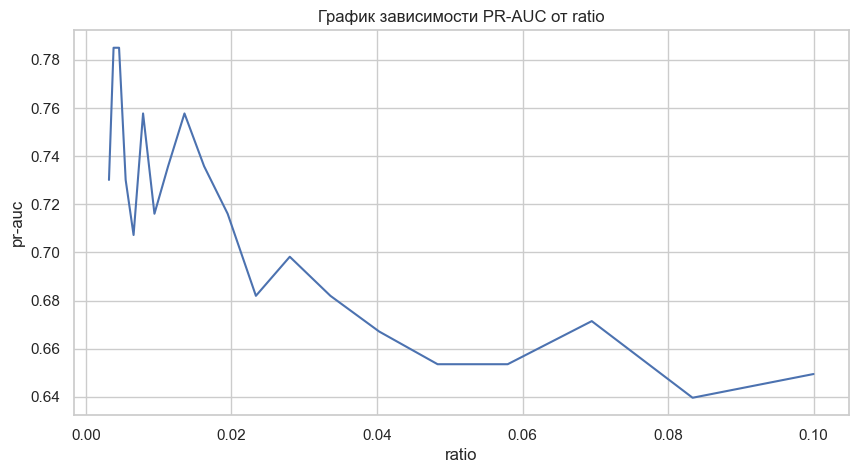

In [281]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.logspace(-2.5, -1, 20)), d['pr_auc'])
plt.title(f'График зависимости PR-AUC от ratio')
plt.ylabel('pr-auc')
plt.xlabel('ratio')
plt.show()

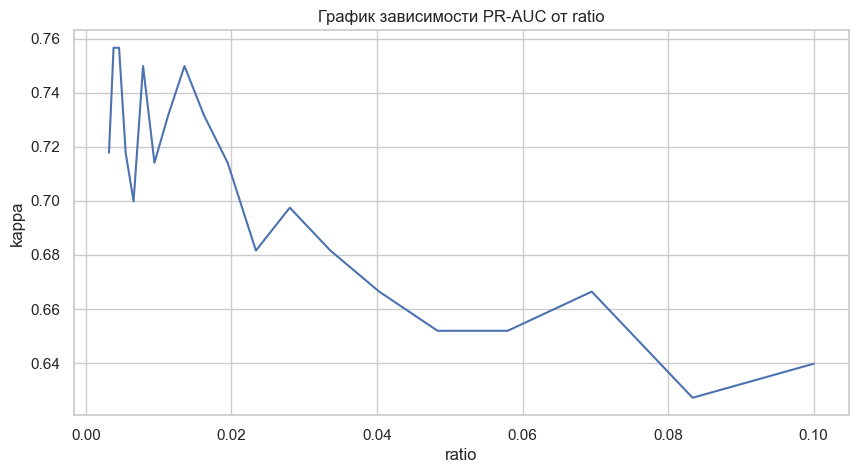

In [282]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.logspace(-2.5, -1, 20)), d['kappa'])
plt.title(f'График зависимости PR-AUC от ratio')
plt.ylabel('kappa')
plt.xlabel('ratio')
plt.show()

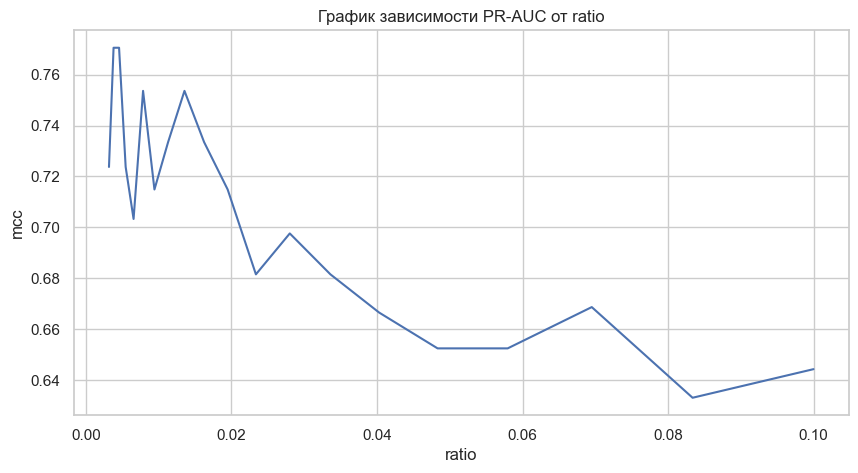

In [283]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.logspace(-2.5, -1, 20)), d['mcc'])
plt.title(f'График зависимости PR-AUC от ratio')
plt.ylabel('mcc')
plt.xlabel('ratio')
plt.show()

Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять нам качество - например, мы можем при отбрасывании использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируйте алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и постройте графики, аналогичные предыдущему пункту (также добавьте график с зависимостью качества от числа соседей).

In [363]:
from imblearn.under_sampling import NearMiss

d = defaultdict(list)

for i in list(np.linspace(0.1, 1.0, 20)):
    nm = NearMiss(sampling_strategy=i, version=1)
    X_resampled, y_resampled = nm.fit_resample(X_train, y_train)
    
    model = CatBoostClassifier(
        iterations=1000,
        random_seed=42,
        early_stopping_rounds=50,
        verbose=0
    )
    model.fit(X_resampled, y_resampled)
    
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > best).astype(int)
    
    d['pr_auc'].append(pr_auc_score(y_test, y_pred))
    d['kappa'].append(kappa_score(y_test, y_pred))
    d['mcc'].append(mcc_score(y_test, y_pred))

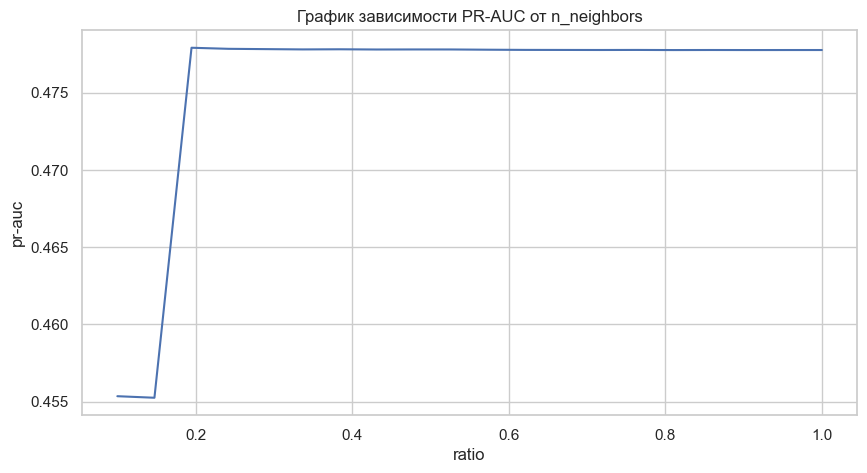

In [367]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.linspace(0.1, 1., 20)), d['pr_auc'])
plt.title(f'График зависимости PR-AUC от n_neighbors')
plt.ylabel('pr-auc')
plt.xlabel('ratio')
plt.show()

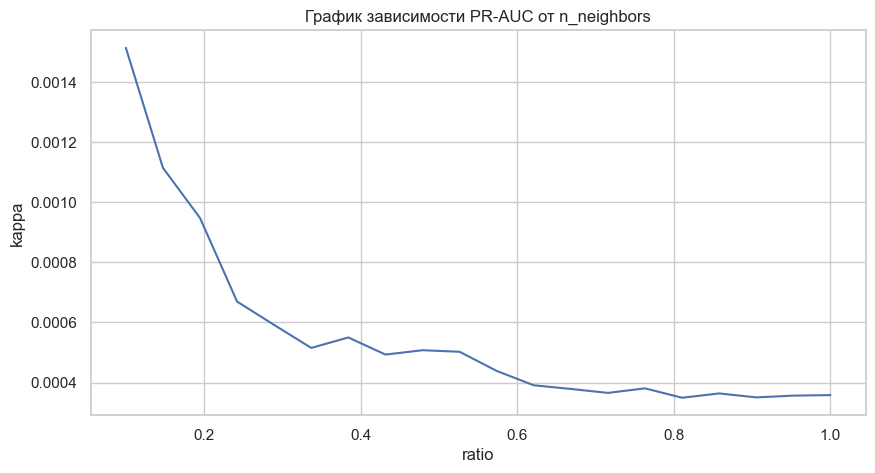

In [369]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.linspace(0.1, 1., 20)), d['kappa'])
plt.title(f'График зависимости PR-AUC от n_neighbors')
plt.ylabel('kappa')
plt.xlabel('ratio')
plt.show()

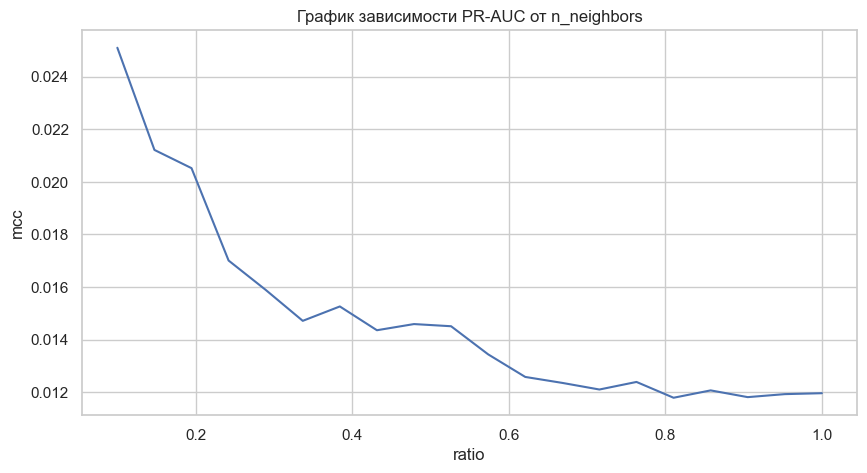

In [370]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.linspace(0.1, 1.0, 20)), d['mcc'])
plt.title(f'График зависимости PR-AUC от n_neighbors')
plt.ylabel('mcc')
plt.xlabel('ratio')
plt.show()

In [355]:
from imblearn.under_sampling import NearMiss

d = defaultdict(list)

for i in list(np.arange(1, 9)):
    nm = NearMiss(sampling_strategy=0.1, version=1, n_neighbors=i)
    X_resampled, y_resampled = nm.fit_resample(X_train, y_train)
    
    model = CatBoostClassifier(
        iterations=1000,
        random_seed=42,
        early_stopping_rounds=50,
        verbose=0
    )
    model.fit(X_resampled, y_resampled)
    
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs > best).astype(int)
    
    d['pr_auc'].append(pr_auc_score(y_test, y_pred))
    d['kappa'].append(kappa_score(y_test, y_pred))
    d['mcc'].append(mcc_score(y_test, y_pred))

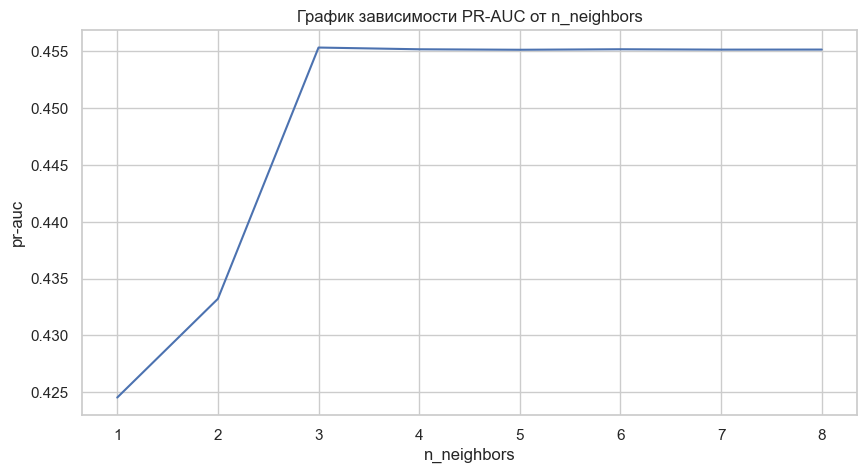

In [359]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.arange(1, 9)), d['pr_auc'])
plt.title(f'График зависимости PR-AUC от n_neighbors')
plt.ylabel('pr-auc')
plt.xlabel('n_neighbors')
plt.show()

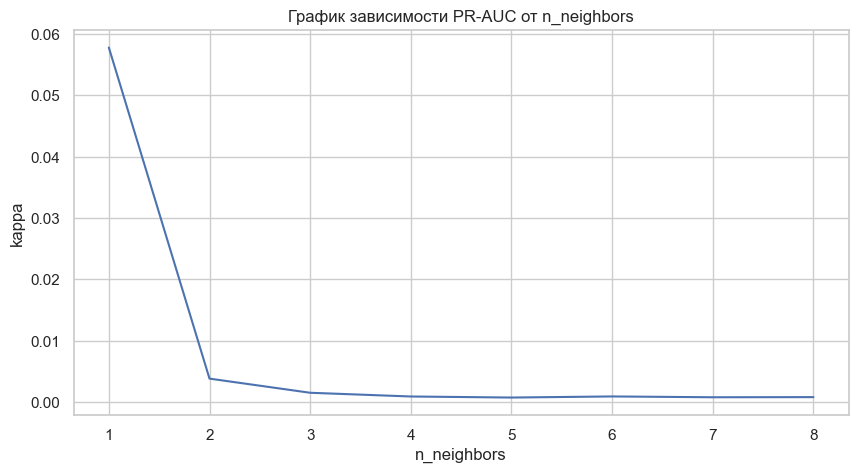

In [360]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.arange(1, 9)), d['kappa'])
plt.title(f'График зависимости PR-AUC от n_neighbors')
plt.ylabel('kappa')
plt.xlabel('n_neighbors')
plt.show()

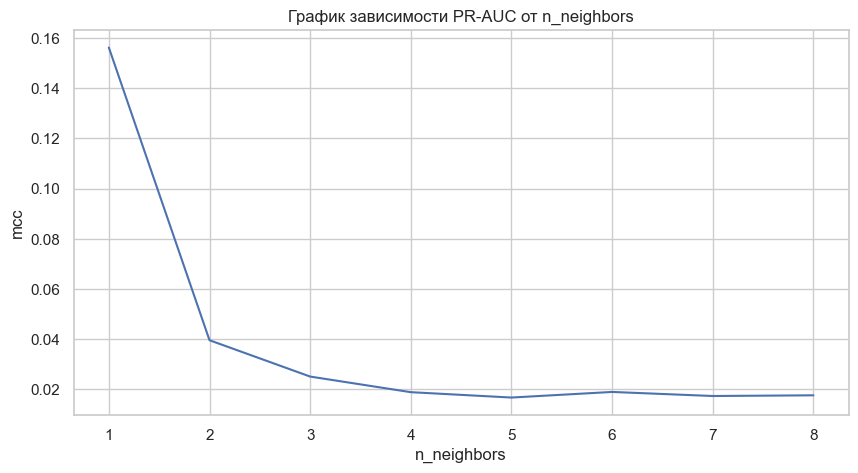

In [362]:
plt.figure(figsize=(10, 5))
plt.plot(list(np.arange(1, 9)), d['mcc'])
plt.title(f'График зависимости PR-AUC от n_neighbors')
plt.ylabel('mcc')
plt.xlabel('n_neighbors')
plt.show()

**Бонус (1 балл)**. imblearn также предлагает много различных методов для андерсэмплинга. Выберите что-нибудь еще из предлагаемого на свой вкус, опишите идею метода и протестируйте его.


# Часть 2. Поиск аномалий. 

Как вы могли заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка. 

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу "одноклассовой" классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных). 

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



**Задание 4. (3 балла).** На занятиях вы разбирали схожий с Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

В данном задании вам предлагается реализовать модификацию данного алгоритма, известную как Extended Isolation Forest. В ней мы на каждом шаге будем определять не порог для признака, а полноценную случайную гиперплоскость, разбивающую выборку на 2 части. С детальным описанием вы можете ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

Ниже приведен шаблон кода. Постарайтесь работать в его рамках (минорные изменения вполне допустимы, главное не переворачивайте всю структуру с ног на голову). 

**NB**: будем считать, что в нашем датасете нет категориальных признаков - можете не заморачиваться с их обработкой (но в общем случае, это будет важно).

**Советы**:
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, вам поможет выбрасывание некоторых признаков.
 - Внимательно следите за знаками.
 - Не игнорируйте документирующие строки.
 - Вероятнее всего, вы не сможете приблизиться по качеству к supervised-решениям. Если у вас не получается это сделать (но вы уверены в своей правоте), не стоит тратить слишком много времени на поиск ошибок.
- При желании, можете вынести этот код в отдельный файл и приложить его к ноутбуку. Он довольно громоздкий и в ноутбуке такое плохо читается.


**Бонусы (каждый по 0.5)**:
- Сделайте ваш EIF параллельным (`multiprocessing`, `joblib`).
- Добавьте возможность откатиться к дефолтному варианту Isolation Forest. (порассуждайте, как можно реализовать это в данной модели?):


In [ ]:
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_random_state

def c_factor(n):
    """
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    """
    if n <= 1:
        return 0
    elif n == 2:
        return 1
    return 2 * (np.log(n - 1) + 0.5772156649) - 2 * (n - 1) / n

def calc_height(X, depth, node):
    """
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node
        
        depth: int - path length up to current node
        
        node: Node - current tree node
        
    Returns:
        scores: int, float or np.array - anomaly scores for sample
    """
    scores = np.zeros(X.shape[0])
    
    if node.kind == "external":
        scores += depth + c_factor(node.size)
        return scores
    
    direction = np.sign(node.w.dot(X.T) + node.b)
    left_mask = direction < 0
    right_mask = ~left_mask
    
    if np.any(left_mask):
        scores[left_mask] = calc_height(X[left_mask], depth + 1, node.left)
    if np.any(right_mask):
        scores[right_mask] = calc_height(X[right_mask], depth + 1, node.right)
    
    return scores

class Node(object):
    """
    A single node object for each tree. Contains information on height, current data,
    splitting hyperplane and children nodes.
    
    Attributes:
        X: np.array - data available to current node
        size: int - length of available data
        
        depth: int - depth of node

        left: Node - left child
        right: Node - right child

        kind: str - either "internal" or "external", indicates the type of current node

        w: np.array - normal vector for the splitting hyperplane
        b: float - intercept term for the splitting hyperplane
    """
    def __init__(self, X, depth, left, right, kind, w, b):
        """
        Node(h, left, right, kind, w, b)
        Represents the node object.
        
        Params:
            X: np.array - data available to current node
            depth: int - depth of node
            
            left: Node - left child
            right: Node - right child
            
            kind: str - either "internal" or "external", indicates the type of current node
            
            w: np.array - normal vector for the splitting hyperplane
            b: float - intercept term for the splitting hyperplane
            
        """
        self.X = X
        self.size = len(X)
        self.depth = depth
        self.left = left
        self.right = right
        self.kind = kind
        self.w = w
        self.b = b
    
    def __repr__(self):
        """
        For convenience only.
        """
        return f"Node(size={self.size}, depth={self.depth}, kind={self.kind})"

class RandomizedTree(object):
    """
    Single randomized tree object. Stores root and its depth (tree is built recursively).
    Attributes:
        depth: int - current tree depth
        
        max_depth: int - maximum tree depth
        
        root: Node - root node 

        internal_count: int - number of internal nodes

        external_count: int - number of external nodes
        
    """
    def __init__(self, X, max_depth, random_state=None):
        """
        Single randomized tree object. Stores root and its depth (tree is built recursively).
        Params:
            X: np.array - train sample
            max_depth: int - maximum tree depth

        """
        self.depth = 0
        self.max_depth = max_depth
        self.internal_count = 0
        self.external_count = 0
        self.random_state = check_random_state(random_state)
        self.root = self.grow(X, 0)
        
    def __repr__(self):
        """
        For convenience only.
        """
        return f"RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, n_internal={self.internal_count}, n_external={self.external_count})"
        
    def grow(self, X, depth):
        """
        Grow tree in a recursive manner.
        Params:
            X: np.array - available train sample
            
            depth: int - current tree depth
            
        Returns:
            node: Node - a trained node with separating hyperplane data.
                         Node provides access to children if necessary (these are built recursively)
        """
        if depth >= self.max_depth or len(X) <= 1:
            self.external_count += 1
            return Node(X, depth, None, None, "external", None, None)
        
        n_features = X.shape[1]
        
        w = self.random_state.normal(size=n_features)
        b = self.random_state.normal()
        
        direction = np.sign(w.dot(X.T) + b)
        left_mask = direction < 0
        right_mask = ~left_mask
        
        if not np.any(left_mask) or not np.any(right_mask):
            self.external_count += 1
            return Node(X, depth, None, None, "external", None, None)
        
        left = self.grow(X[left_mask], depth + 1)
        right = self.grow(X[right_mask], depth + 1)
        
        self.internal_count += 1
        return Node(X, depth, left, right, "internal", w, b)

    def score_samples(self, X):
        """
        Calculate anomaly scores for given data. You may utilize outer function `calc_height`.
        Params:
            X: np.array - data to be evaluated
            
        Returns:
            scores: np.array - estimated anomaly scores
        """
        return calc_height(X, 0, self.root)
        
class ExtendedIsolationForest(object):
    """
    Extended Isolation Forest object. Stores training data and trained randomized trees.
    Attributes:
        n_trees: int - number of Randomized Trees
        
        max_depth: int - maximum depth of each tree
        
        subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree
        
        trees: list - container for trained trees 
        
        contamination: float - estimated fraction of anomaly samples in data. Used for thresholding
        
    """
    def __init__(self, n_trees=100, subsample_rate=0.1, max_depth=None, 
                 contamination=0.01, random_state=None, n_jobs=None,
                 use_original_if=False):
        """
        Extended Isolation Forest object. Stores training data and trained randomized trees.
        Params:
            n_trees: int - number of Randomized Trees

            subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

            max_depth: int or None - maximum depth of each tree. Defaults to ceil(log_2(subsample_size)) if not provided

            contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.contamination = contamination
        self.random_state = check_random_state(random_state)
        self.n_jobs = n_jobs
        self.use_original_if = use_original_if
        self.trees = []
        self.scaler = StandardScaler()
        self.is_fit = False
        
    def __repr__(self):
        """For convenience only."""
        return f"ExtendedIsolationForest(n_trees={self.n_trees}, max_depth={self.max_depth}, subsample_rate={self.subsample_rate}, contamination={self.contamination}, is_fit={self.is_fit})"
        
    def fit(self, X):
        """
        Fit EIF to new data.
        Params:
            X: np.array - 2d array of samples
        """
        X = self.scaler.fit_transform(X)
        n_samples = X.shape[0]
        subsample_size = int(self.subsample_rate * n_samples)
        
        if self.max_depth is None:
            self.max_depth = int(np.ceil(np.log2(subsample_size)))
        
        seeds = self.random_state.randint(0, np.iinfo(np.int32).max, self.n_trees)
        
        self.trees = Parallel(n_jobs=self.n_jobs)(
            delayed(self._fit_tree)(X, subsample_size, seed, idx)
            for idx, seed in enumerate(seeds))
        
        self.is_fit = True
        return self
    
    def _fit_tree(self, X, subsample_size, seed, idx):
        rng = check_random_state(seed)
        subsample_idx = rng.choice(X.shape[0], size=subsample_size, replace=False)
        subsample = X[subsample_idx]
        return RandomizedTree(subsample, self.max_depth, rng)
    
    def score_samples(self, X):
        """
        Estimate (normalized) anomaly score for each given sample
        Params:
            X: np.array - new samples

        Returns:
            scores: np.array - anomaly scores (larger value means higher probability of a sample being an outlier)
        """
        if not self.is_fit:
            raise RuntimeError("The model has not been fitted yet.")
            
        X = self.scaler.transform(X)
        all_scores = np.zeros(X.shape[0])
        
        scores = Parallel(n_jobs=self.n_jobs)(
            delayed(tree.score_samples)(X) for tree in self.trees)
        
        all_scores = np.mean(scores, axis=0)
        
        all_scores = 2 ** (-all_scores / c_factor(int(self.subsample_rate * X.shape[0])))
        return all_scores
    
    def predict(self, X):
        """
        Predict if given samples are outliers.
        Params:
            X: np.array - new samples

        Returns:
            labels: np.array - anomaly labels (1 for outliers, 0 for inliers)
        """
        scores = self.score_samples(X)
        threshold = np.quantile(scores, 1 - self.contamination)
        return (scores >= threshold).astype(int)

**Задание 5. (1 балл).** Протестируйте вашу реализацию EIF и подберите оптимальные гиперпараметры (наш метод не использует разметку, поэтому можете попробовать делать это на обучающей выборке). Сравните ее с обычным IF из `sklearn` (желательно делать это на одних и тех же параметрах). Удалось ли сделать лучше?

In [32]:
import optuna
def objective(trial):
    params = {
        'n_trees': trial.suggest_int('n_trees', 1, 5),
        'subsample_rate': trial.suggest_float('subsample_rate', 0.1, 1, step=0.1),
        'contamination': trial.suggest_float('contamination', 0.01, 0.5, step=0.01)
    }
    y_pred = ExtendedIsolationForest(**params).fit(X_train).predict(X_val)
    return pr_auc_score(y_pred, y_val)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10, n_jobs=-1)

[I 2025-05-18 22:59:54,459] A new study created in memory with name: no-name-d3db17fb-baa8-4d3d-986d-6b70666ff4bc
[I 2025-05-18 23:00:04,916] Trial 1 finished with value: 0.637421638517765 and parameters: {'n_trees': 1, 'subsample_rate': 0.30000000000000004, 'contamination': 0.46}. Best is trial 1 with value: 0.637421638517765.
[I 2025-05-18 23:00:05,070] Trial 5 finished with value: 0.31351440896996524 and parameters: {'n_trees': 1, 'subsample_rate': 0.30000000000000004, 'contamination': 0.35000000000000003}. Best is trial 1 with value: 0.637421638517765.
[I 2025-05-18 23:00:08,519] Trial 7 finished with value: 0.49567806457015307 and parameters: {'n_trees': 3, 'subsample_rate': 0.1, 'contamination': 0.29000000000000004}. Best is trial 1 with value: 0.637421638517765.
[I 2025-05-18 23:00:10,638] Trial 3 finished with value: 0.4063464826665772 and parameters: {'n_trees': 1, 'subsample_rate': 0.6, 'contamination': 0.22}. Best is trial 1 with value: 0.637421638517765.
[I 2025-05-18 23:00

In [44]:
model = ExtendedIsolationForest(**study.best_params).fit(X_train)
y_pred = model.predict(X_test)

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))


Test metrics:
PR-AUC: 0.38711459281034566
Kappa: 0.0011077013922544418
MCC: 0.018035862927093152


In [45]:
from sklearn.ensemble import IsolationForest

y_pred = IsolationForest(n_estimators=study.best_params['n_trees'], contamination=study.best_params['contamination'], random_state=42).fit(X_train).predict(X_test)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

print("\nTest metrics:")
print("PR-AUC:", pr_auc_score(y_test, y_pred))
print("Kappa:", kappa_score(y_test, y_pred))
print("MCC:", mcc_score(y_test, y_pred))


Test metrics:
PR-AUC: 0.4781433165848101
Kappa: 0.0018668494619154062
MCC: 0.02931854288707364


Не, лучше сделать не удалось. 

Возможно, ваш алгоритм выдал большие оценки объектам с негативной разметкой. Постарайтесь выбрать несколько таких объектов и доступно объяснить (= с кодом и графиками), почему так вышло:

In [52]:
scores = model.score_samples(X_test)
scores -= np.percentile(scores, 100.0 * model.contamination)
X_test[y_test == 1][scores[y_test == 1] > 0][:5]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour,Day
258403,-3.051076,-4.358357,-3.553707,3.605425,3.388192,-4.178489,-3.468766,0.733897,-0.978926,-3.005534,1.144512,-2.136442,1.133673,-4.763237,-0.138696,-3.226227,-3.374108,-1.089193,0.517351,4.068286,1.986826,-0.187766,1.358259,-0.445667,-2.100724,-1.474215,1.401887,-3.132873,296.00,20,1
261056,-0.208359,1.897253,-2.043215,4.099182,0.645255,-0.376406,-0.355717,0.495523,-2.974334,-2.041672,0.741702,-3.504609,0.247914,-6.327624,0.371002,-1.147756,0.393620,0.502594,1.532043,0.648012,0.134077,-0.741869,-0.349084,-1.721561,0.603113,1.126533,0.579367,0.362344,45.51,20,1
261473,-1.199443,0.916005,-1.746080,1.238671,0.294388,-1.642682,-0.555282,-0.458814,-0.090593,-1.535886,2.128884,-3.105963,0.218594,-6.295056,0.179611,-2.720482,-4.905574,-2.114591,-0.646506,-0.121181,-0.120513,-0.820143,0.413395,0.102207,-0.679447,-2.390312,-1.823624,2.222785,4.90,20,1
261925,-1.421288,0.967007,-1.374998,1.774875,-1.048183,-0.621868,-0.591922,-0.170242,-0.315889,-1.985641,1.926229,-3.129961,0.508980,-6.182108,1.017236,-2.852272,-4.371360,-1.362644,0.769301,-0.668031,0.277137,0.404117,0.319586,0.242497,0.313848,-1.294174,-3.302762,1.298566,156.00,20,1
262560,0.289754,2.004102,-4.373460,4.516369,-0.039248,-1.798838,-2.257302,0.431038,-3.223815,-4.899448,3.545309,-7.107177,-0.444225,-11.560283,-0.889008,-3.769351,-6.886445,-2.207935,-1.251339,0.720450,0.836218,-0.503028,-0.288904,-0.863989,1.237450,0.511100,2.236382,1.434706,4.69,20,1


Я абсолютно хз ваще. 

**Задание 6. (1 балл).** `sklearn` также предлагает нам и другие методы для поиска аномалий. В этом задании мы предлагаем вам сделать следующее:

Для начала попробуйте использовать методы Local Outlier Factor и One-Class SVM. Сравните результаты с IF и EIF.  

In [ ]:
#your code here

У вас началась депрессия из-за плохих метрик? Не беда! Сейчас давайте сделаем так: все методы, опробованные в этой части, попробуем задействовать для создания дополнительных признаков в данных. Проделайте это (не забудьте, что обучаться здесь нужно на трейне). Теперь возьмите лучшую модель из предыдущей части и обучите на новых данных. Смогли ли unsupervised-методы повысить вам качество?

In [ ]:
#your code here

**Бонус. (0.1 балла).**

При сдаче проверяющий запустит следующую клетку один раз. Если она даст положительный результат, вы получите 0.1 бонусных балла. Если она даст отрицательный результат, вы получите -0.1 бонусных балла. 

Если вы хотите отказаться от сдачи данного задания, допишите "хочу" после двоеточия: хочу

Ниже вы можете попрактиковаться и оценить ваши силы (изменять код ячейки запрещается!)

In [371]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)

-0.6732602581638234

Ненавижу эту дз. Вот мои чувства по отношению к нему:

<img src="https://media1.tenor.com/m/gv4V0qyiWLcAAAAC/star-wars-i-hate-you.gif">